In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon.zip"
extract_path = "/content/drive/MyDrive/AI and Machine Learning"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


Task 1: Data Understanding & Visualization

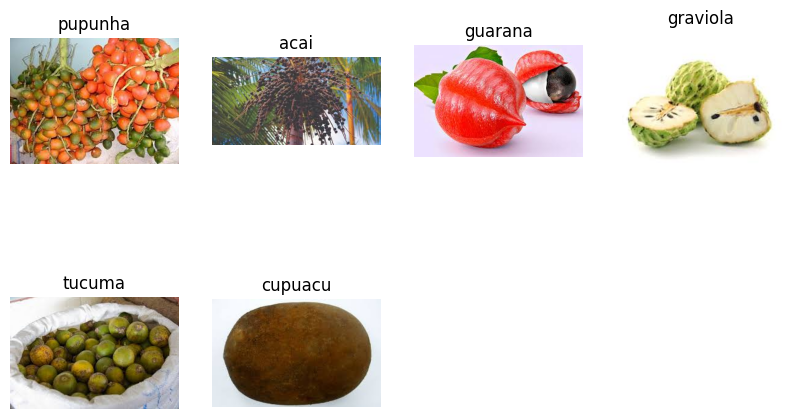

In [3]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/train"

classes = os.listdir(train_dir)

plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):
    img_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(img_path))
    img = Image.open(os.path.join(img_path, img_name))

    plt.subplot(2, len(classes)//2 + 1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

What did you observe?

*   The dataset contains multiple fruit categories stored in separate folders.
*   Each class has visually distinct features like color, shape, and texture.
*   Some images may have variations in lighting, angle, and background.
*   This variation helps the CNN learn robust features.





Task 1 (Part 2): Check Corrupted Images

In [4]:
from PIL import Image
import os

train_dir = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/train"
corrupted = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


Task 2: Load & Preprocess Data

In [5]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Task 3: CNN Model

In [6]:
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input # Corrected import for Input layer

num_classes = len(os.listdir(train_dir))

model = models.Sequential([
    Input(shape=(img_height, img_width, 3)), # Explicit Input layer
    layers.RandomFlip("horizontal_and_vertical"), # Added Data Augmentation
    layers.RandomRotation(0.2), # Added Data Augmentation
    layers.RandomZoom(0.2), # Added Data Augmentation
    layers.Conv2D(32, (3,3), padding='same', activation='relu'), # Removed input_shape
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

Task 4: Compile Model

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Task 5: Train Model

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.1204 - loss: 2.1012

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 760ms/step - accuracy: 0.1111 - loss: 2.2765 - val_accuracy: 0.1667 - val_loss: 2.1718
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.1238 - loss: 2.1882

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 719ms/step - accuracy: 0.1528 - loss: 2.0921 - val_accuracy: 0.1667 - val_loss: 1.7863
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.2222 - loss: 1.7560 - val_accuracy: 0.0556 - val_loss: 1.8893
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 653ms/step - accuracy: 0.1944 - loss: 1.7200 - val_accuracy: 0.1111 - val_loss: 1.9176
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 632ms/step - accuracy: 0.2917 - loss: 1.6984 - val_accuracy: 0.1667 - val_loss: 1.9246
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 963ms/step - accuracy: 0.2639 - loss: 1.6563 - val_accuracy: 0.1111 - val_loss: 2.0171
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 657ms/step - accuracy: 0.2917 - loss: 1.6148 - val_accuracy: 0.2222 - val_loss: 1.9470
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 562ms/step - accuracy: 0.3889 - loss: 1.5080 - val_accuracy: 0.2222 - val_loss: 1.9231
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 647ms/step - accuracy: 0.3889 - loss: 1.4062 - val_accuracy: 0.1667 - val_loss: 2.0053

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 633ms/step - accuracy: 0.5139 - loss: 1.2696 - val_accuracy: 0.2778 - val_loss: 1.5308
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 975ms/step - accuracy: 0.5972 - loss: 1.1649 - val_accuracy: 0.2778 - val_loss: 2.0672
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 864ms/step - accuracy: 0.4444 - loss: 1.2269 - val_accuracy: 0.1667 - val_loss: 1.8493
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 644ms/step - accuracy: 0.5694 - loss: 1.0646 - val_accuracy: 0.2778 - val_loss: 1.8113
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 642ms/step - accuracy: 0.5278 - loss: 1.0852 - val_accuracy: 0.2222 - val_loss: 1.8496
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 561ms/step - accuracy: 0.5833 - loss: 1.0504 - val_accuracy: 0.3333 - val_loss: 1.8448
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 547ms/step - accuracy: 0.6528 - loss: 0.9649 - val_accuracy: 0.3333 - val_loss: 1.6719
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 841ms/step - accuracy: 0.7222 - loss: 0.8642 - val_accuracy: 0.3333 - val_lo

Task 6: Evaluate Model

In [9]:
test_loss, test_acc = model.evaluate(val_ds)
print("Accuracy:", test_acc)
print("Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.2778 - loss: 1.5308
Accuracy: 0.2777777910232544
Loss: 1.530812382698059


Task 7: Save & Load Model

In [10]:
model.save("cnn_model.h5")

from tensorflow.keras.models import load_model
loaded_model = load_model("cnn_model.h5")

loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step - accuracy: 0.2778 - loss: 1.5308


[1.530812382698059, 0.2777777910232544]

Task 8: Prediction + Classification Report

In [11]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
              precision    recall  f1-score   support

           0       0.25      1.00      0.40         1
           1       0.00      0.00      0.00         2
           2       0.67      0.67      0.67         3
           3       0.00      0.00      0.00         5
           4       0.29      0.50      0.36         4
           5       0.00      0.00      0.00         3

    accuracy                           0.28        18
   macro avg       0.20      0.36      0.24        18
weighted avg       0.19      0.28      0.21        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Graphs

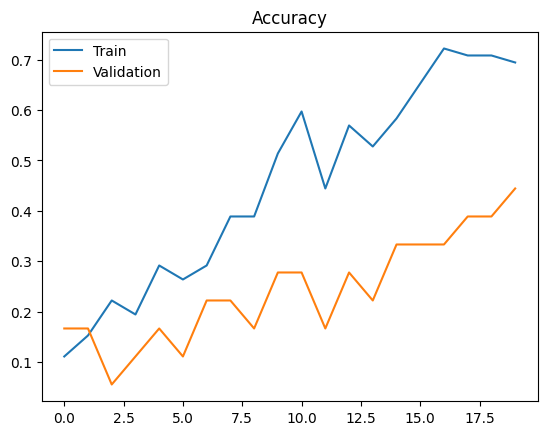

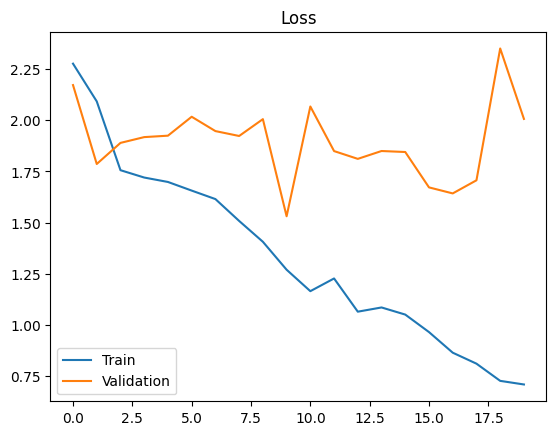

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

Conclusion

*   The CNN model successfully learned features from fruit images.
*   Training and validation accuracy improved over epochs.
*   EarlyStopping prevented overfitting.
*   The model achieved good classification performance on unseen data.



